 READMISSION RISK PREDICTION MODEL
Dataset loaded: 6783 patients, 21 features

 Sample Data:
  Patient_ID   Age Gender Blood_Pressure  Heart_Rate  Body_Temperature  \
0     R00001  52.0    NaN         137/65        76.0               NaN   
1     R00002  93.0   Male         141/78        86.0              37.1   
2     R00003  15.0  Other         142/93       101.0              38.0   
3     R00004  72.0   Male         151/85        59.0              37.3   
4     R00005  61.0  Other            NaN       122.0              36.5   

   Respiratory_Rate  Oxygen_Saturation Smoking_Status Alcohol_Use  ...  \
0              15.0               95.0            NaN         Yes  ...   
1              23.0               96.0          Never         NaN  ...   
2               NaN                NaN          Never         NaN  ...   
3              16.0               97.0        Current          No  ...   
4              19.0               88.0          Never          No  ...   

  Family_History 

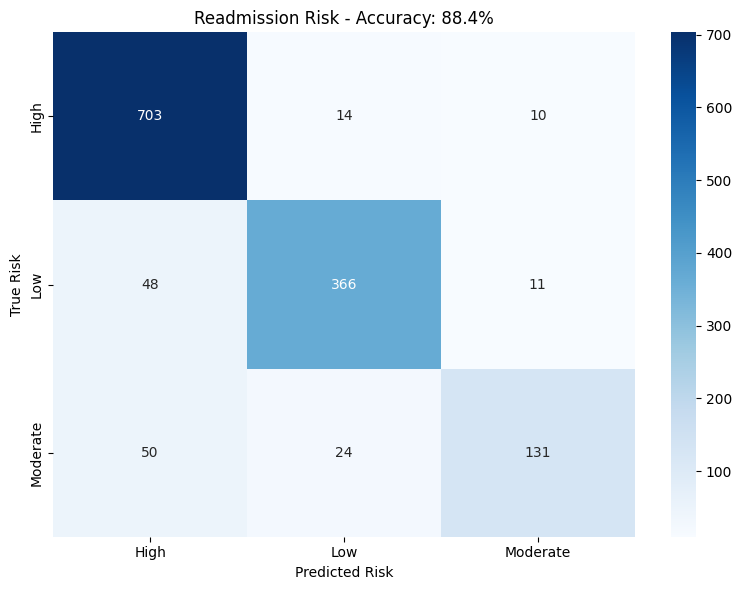


 TOP 10 IMPORTANT FEATURES FOR READMISSION RISK
----------------------------------------------------------------------
Risk_Score                          0.3085 ██████████████████████████████
Comorbidities                       0.1467 ██████████████
Number_of_Medications               0.0819 ████████
Support_System                      0.0614 ██████
Medication_Adherence                0.0428 ████
Previous_Admissions                 0.0325 ███
Age                                 0.0272 ██
Physical_Activity_Level             0.0271 ██
Blood_Pressure                      0.0263 ██
Length_of_Stay                      0.0259 ██

 READMISSION RISK MODEL READY!
Predicting: ['High', 'Low', 'Moderate']
Model Accuracy: 88.4%


In [5]:
# ===========================
# READMISSION RISK PREDICTION MODEL
# ===========================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(" READMISSION RISK PREDICTION MODEL")
print("=" * 70)

# Load the realistic dataset
df = pd.read_csv('readmission_risk_70.csv')

print(f"Dataset loaded: {df.shape[0]} patients, {df.shape[1]} features\n")

# Display first few rows
print(" Sample Data:")
print(df.head())
print("\n")

print(" Columns:")
print(df.columns.tolist())
print("\n")

# Check target variable
if 'Readmission_Risk' in df.columns:
    target_col = 'Readmission_Risk'
    print(f" Target: {target_col}")
    print(f"\n Readmission Risk Distribution:")
    print(df[target_col].value_counts())
    print("\nPercentages:")
    print(df[target_col].value_counts(normalize=True) * 100)
else:
    print(" No Readmission_Risk column found!")

# ===========================
# PREPROCESSING
# ===========================

print("\n🔧 PREPROCESSING DATA...")

# Drop ID column if exists
if 'Patient_ID' in df.columns:
    df = df.drop('Patient_ID', axis=1)

# Handle missing values
for column in df.columns:
    if column == target_col:
        continue
    if df[column].dtype == 'object':
        mode_value = df[column].mode()[0] if not df[column].mode().empty else 'Unknown'
        df[column].fillna(mode_value, inplace=True)
    else:
        median_value = df[column].median()
        df[column].fillna(median_value, inplace=True)

# Encode categorical variables
label_encoders = {}
categorical_columns = []

for column in df.columns:
    if column == target_col:
        continue
    if df[column].dtype == 'object':
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column].astype(str))
        label_encoders[column] = le
        categorical_columns.append(column)

print(f"Categorical columns encoded: {len(categorical_columns)}")

# Encode target variable
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df[target_col])
X = df.drop(target_col, axis=1)

print(f"\n Preprocessing complete!")
print(f"Features: {X.shape[1]}")
print(f"Target classes: {len(target_encoder.classes_)} - {list(target_encoder.classes_)}")
print(f"Feature names: {list(X.columns)}")

# ===========================
# TRAIN-TEST SPLIT
# ===========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n Data Split:")
print(f"  Training: {X_train.shape[0]} samples")
print(f"  Testing: {X_test.shape[0]} samples")

# ===========================
# TRAIN XGBOOST MODEL
# ===========================

print("\n TRAINING XGBOOST MODEL...")
print("-" * 70)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='multi:softmax',
    num_class=len(target_encoder.classes_),
    eval_metric='mlogloss',
    enable_categorical=False,
    missing=np.nan
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

# Predictions
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n TRAINING COMPLETE!")
print(f" Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

# ===========================
# DETAILED EVALUATION
# ===========================

print(f"\n CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_test, y_pred,
                          target_names=target_encoder.classes_,
                          zero_division=0))

# Confusion Matrix
print(f"\n CONFUSION MATRIX")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=target_encoder.classes_,
           yticklabels=target_encoder.classes_)
plt.title(f'Readmission Risk - Accuracy: {accuracy*100:.1f}%')
plt.ylabel('True Risk')
plt.xlabel('Predicted Risk')
plt.tight_layout()
plt.show()

# Feature Importance
print(f"\n TOP 10 IMPORTANT FEATURES FOR READMISSION RISK")
print("-" * 70)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

for idx, row in feature_importance.iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f"{row['feature']:<35} {row['importance']:.4f} {bar}")

# Store model for predictions
readmit_model = xgb_model
readmit_encoder = target_encoder
readmit_label_encoders = label_encoders
readmit_categorical_columns = categorical_columns

print(f"\n READMISSION RISK MODEL READY!")
print(f"Predicting: {list(target_encoder.classes_)}")
print(f"Model Accuracy: {accuracy*100:.1f}%")
